# Practical 06: Neural Network Classification – Food Vendor Dataset

## Objective
To classify food vendors into categories using a Neural Network model and evaluate performance using accuracy and confusion matrix.

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Load Dataset

In [4]:
df = pd.read_csv("food_vendor_consultation.csv")
df.head()

,foot_traffic,avg_income,competitor_count,rent_cost,population_density,parking_score,visibility_score,hygiene_rating,marketing_score,vendor_category
0,699.0,81.0,3,138.4,68.9,2,2,4.1,81.7,0
1,572.0,73.9,6,100.8,93.1,6,2,4.9,55.4,1
2,730.0,60.9,4,72.9,60.1,3,6,2.4,73.8,1
3,905.0,50.3,6,148.2,61.1,2,1,2.6,63.0,0
4,553.0,70.5,9,107.1,77.2,1,6,4.6,67.3,1


## Feature & Target Split

In [5]:
X = df.drop("vendor_category", axis=1)
y = df["vendor_category"]

## Feature Scaling

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Build Neural Network Model

In [8]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [9]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Train Model

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2556 - loss: 1.2641 - val_accuracy: 0.3500 - val_loss: 1.1114
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3389 - loss: 1.1544 - val_accuracy: 0.4500 - val_loss: 1.0450
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4319 - loss: 1.0824 - val_accuracy: 0.4875 - val_loss: 0.9952
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4986 - loss: 1.0273 - val_accuracy: 0.5125 - val_loss: 0.9625
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5389 - loss: 0.9801 - val_accuracy: 0.5125 - val_loss: 0.9322
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5667 - loss: 0.9433 - val_accuracy: 0.5375 - val_loss: 0.9083
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5931 - loss: 0.9103 - val_accuracy: 0.5500 - val_loss: 0.8891
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5972 - loss: 0.8825 - val_accuracy: 0.5375 - val_loss:

## Prediction

In [11]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Accuracy: 0.61


## Confusion Matrix

[[45 18  1]
 [19 29 23]
 [ 3 14 48]]


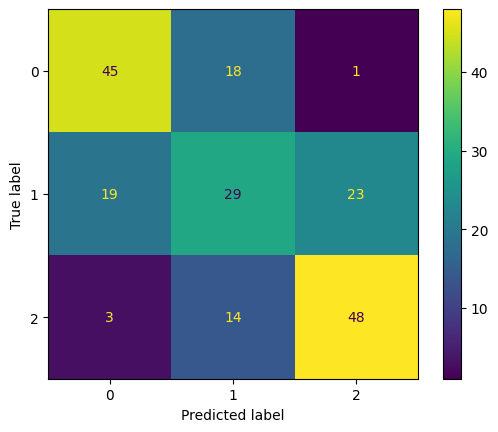

In [12]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Visualization: Loss Curve

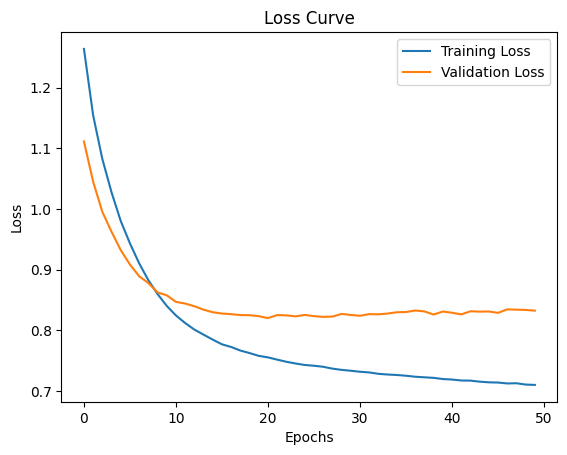

In [13]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

## Visualization: Accuracy Curve

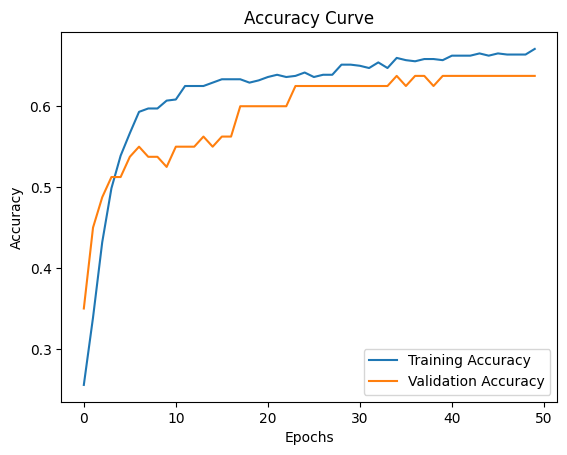

In [14]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

## Conclusion

A Neural Network model successfully classified food vendors into categories. Accuracy and confusion matrix confirmed effective classification performance.